<a href="https://colab.research.google.com/github/mabitha-7/mlops_training/blob/main/MLOPS%20EXCERCISE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
EXERCISE 1

IMPORT THE REQUIRED LIBRARIES FOR THE GIVEN HIRING DATASET

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import math

READ AND PRINT THE DATASET

In [ ]:
df = pd.read_csv("hiring.csv")
print(df)

  experience  test_score  interview_score  salary
0        NaN         8.0                9   50000
1        NaN         8.0                6   45000
2       five         6.0                7   60000
3        two        10.0               10   65000
4      seven         9.0                6   70000
5      three         7.0               10   62000
6        ten         NaN                7   72000
7     eleven         7.0                8   80000


CHECK THE MISSING VALUES

In [ ]:
df.experience = df.experience.fillna("zero")

CONVERT THE WORDS TO NUMBERS

In [ ]:
import pandas as pd
import math
from sklearn.linear_model import LinearRegression
!pip install word2number
from word2number import w2n
df.experience = df.experience.apply(w2n.word_to_num)

  Preparing metadata (setup.py) ... done
  Created wheel for word2number: filename=word2number-1.1-py3-none-any.whl size=5568 sha256=505feaa4c1dce1635ccf07f4cf7a670d843fee22f880c498e4661c34a636f924
  Stored in directory: /root/.cache/pip/wheels/5b/79/fb/d25928e599c7e11fe4e00d32048cd74933f34a74c633d2aea6
Successfully built word2number


FILL THE TEST SCORE MISSING VALUES

In [ ]:
median_test_score = math.floor(df['test_score'].median())
df['test_score'] = df['test_score'].fillna(median_test_score)

CHOOSING THE MODEL

In [ ]:
model = LinearRegression()

TRAIN THE MODEL

In [ ]:
model.fit(
    df[['experience','test_score','interview_score']],
    df['salary']
)

LinearRegression()

PREDICT THE MODEL

In [ ]:
df = pd.read_csv("hiring.csv")
df.experience = df.experience.fillna("zero")
from word2number import w2n
df.experience = df.experience.apply(w2n.word_to_num)
median_test_score = math.floor(df['test_score'].median())
df['test_score'] = df['test_score'].fillna(median_test_score)
model_salary = LinearRegression()
model_salary.fit(
    df[['experience','test_score','interview_score']],
    df['salary']
)
salary1 = model_salary.predict([[2,9,6]])
print(salary1)
salary2 = model_salary.predict([[12,10,10]])
print(salary2)

[53205.96797671]
[92002.18340611]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


**EXERCISE 2t**

IMPORT THE REQUIRED LIBARIES FOR THE GIVEN PER CAPITA DATASET

In [ ]:
import pandas as pd
import numpy as np
from sklearn import linear_model
import matplotlib.pyplot as plt

READ THE FILE AND PRINT THE HEAD

In [ ]:
df = pd.read_csv("canada_per_capita_income.csv")
print(df.head())

   year  per capita income (US$)
0  1970              3399.299037
1  1971              3768.297935
2  1972              4251.175484
3  1973              4804.463248
4  1974              5576.514583


CHOOSING THE MODEL

In [ ]:
model = linear_model.LinearRegression()

TRAIN THE MODEL

In [ ]:
model.fit(df[['year']], df['per capita income (US$)'])

LinearRegression()

PREDICT THE ICOME

In [ ]:
prediction = model.predict([[2020]])
print("Predicted per capita income in 2020:", prediction[0])

Predicted per capita income in 2020: 41288.69409441762


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


**ONE HOT ENCODING EXERCISE**

In [12]:
import pandas as pd
df = pd.read_csv("carprices.csv")
df

,Car Model,Mileage,Sell Price($),Age(yrs)
0,BMW X5,69000,18000,6
1,BMW X5,35000,34000,3
2,BMW X5,57000,26100,5
3,BMW X5,22500,40000,2
4,BMW X5,46000,31500,4
5,Audi A5,59000,29400,5
6,Audi A5,52000,32000,5
7,Audi A5,72000,19300,6
8,Audi A5,91000,12000,8
9,Mercedez Benz C class,67000,22000,6


In [13]:
dummies = pd.get_dummies(df['Car Model'])
dummies

,Audi A5,BMW X5,Mercedez Benz C class
0,False,True,False
1,False,True,False
2,False,True,False
3,False,True,False
4,False,True,False
5,True,False,False
6,True,False,False
7,True,False,False
8,True,False,False
9,False,False,True


In [14]:
merged = pd.concat([df,dummies],axis='columns')
merged

,Car Model,Mileage,Sell Price($),Age(yrs),Audi A5,BMW X5,Mercedez Benz C class
0,BMW X5,69000,18000,6,False,True,False
1,BMW X5,35000,34000,3,False,True,False
2,BMW X5,57000,26100,5,False,True,False
3,BMW X5,22500,40000,2,False,True,False
4,BMW X5,46000,31500,4,False,True,False
5,Audi A5,59000,29400,5,True,False,False
6,Audi A5,52000,32000,5,True,False,False
7,Audi A5,72000,19300,6,True,False,False
8,Audi A5,91000,12000,8,True,False,False
9,Mercedez Benz C class,67000,22000,6,False,False,True


In [15]:
final = merged.drop(["Car Model","Mercedez Benz C class"],axis='columns')
final

,Mileage,Sell Price($),Age(yrs),Audi A5,BMW X5
0,69000,18000,6,False,True
1,35000,34000,3,False,True
2,57000,26100,5,False,True
3,22500,40000,2,False,True
4,46000,31500,4,False,True
5,59000,29400,5,True,False
6,52000,32000,5,True,False
7,72000,19300,6,True,False
8,91000,12000,8,True,False
9,67000,22000,6,False,False


In [23]:
X = final.drop('Sell Price($)',axis='columns').astype(int)
X

,Mileage,Age(yrs),Audi A5,BMW X5
0,69000,6,0,1
1,35000,3,0,1
2,57000,5,0,1
3,22500,2,0,1
4,46000,4,0,1
5,59000,5,1,0
6,52000,5,1,0
7,72000,6,1,0
8,91000,8,1,0
9,67000,6,0,0


In [25]:
y = final['Sell Price($)']
y

,Sell Price($)
0,18000
1,34000
2,26100
3,40000
4,31500
5,29400
6,32000
7,19300
8,12000
9,22000


In [26]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [28]:
model.fit(X,y)

LinearRegression()

In [29]:
model.fit(X,y)
model.score(X,y)

0.9417050937281082

In [30]:
model.predict([[45000,4,0,0]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([36991.31721061])

In [31]:
model.predict([[86000,7,0,1]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([11080.74313219])

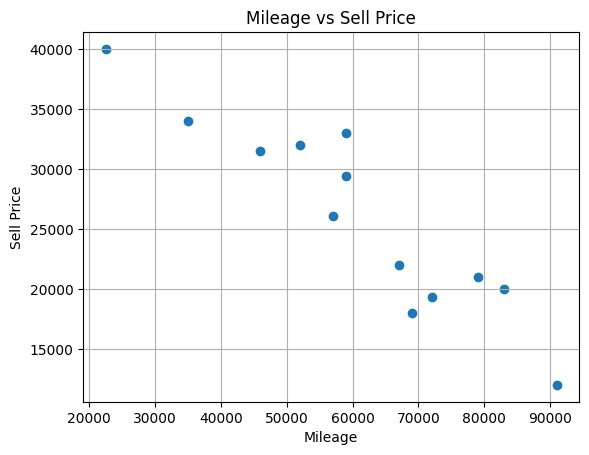

In [33]:
import matplotlib.pyplot as plt

plt.scatter(df['Mileage'], df['Sell Price($)'])

plt.xlabel("Mileage")

plt.ylabel("Sell Price")

plt.title("Mileage vs Sell Price")

plt.grid(True)

plt.show()